# Analysis of Low Birth Rates Across Italian Regions Using Socio-Economic and Demographic Indicators

## 1. Introduction
Italy has experienced a persistent decline in fertility over recent decades, with substantial differences across regions. [MENTION PAPERS] This analysis examines regional fertility patterns using socio-economic and demographic indicators to identify factors associated with low birth rates.

Using two panel datasets covering Italian regions over time, the study first explores descriptive trends and correlations between fertility and key variables. It then applies Random Forest models to capture non-linear relationships and assess the relative importance of demographic structure, labor market conditions, housing costs, family formation, welfare usage, and childcare availability in predicting regional fertility rates.

The objective is not causal inference, but to provide an empirical and data-driven assessment of which factors are most strongly associated with fertility differences across Italian regions.

## 2. Data
The analysis is based exclusively on data from the Italian National Institute of Statistics (ISTAT), ensuring full consistency and comparability across indicators. All variables are collected at the regional level and organized in a panel structure covering multiple years.

In order to align with academic practices and solve missing years of data two different datasets were constructed:
- A long-term dataset covering the period 2011–2024, only including variables with consistent availability over time.
- A short-term dataset covering 2018–2024, which incorporates additional socio-economic indicators with more limited historical coverage.

This dual-dataset strategy allows the analysis to exploit long-term regional trends while also examining the role of more recent labor market and policy-related factors. Descriptive analysis, correlation analysis, and machine-learning models are applied to these datasets to assess associations between fertility and its potential determinants.

In [44]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

DATA_DIR = Path('data/dataset')
lt_path = DATA_DIR / 'dataset_lt.csv'
st_path = DATA_DIR / 'dataset_st.csv'

In [45]:
lt = pd.read_csv(lt_path)
st = pd.read_csv(st_path)

print('LR shape:', lt.shape, '| years:', lt.year.min(), '-', lt.year.max())
print('ST shape:', st.shape, '| years:', st.year.min(), '-', st.year.max())


LR shape: (280, 10) | years: 2011 - 2024
ST shape: (120, 17) | years: 2019 - 2024



### 2.1 Dependent Variable

The dependent variable is the Total Fertility Rate (TFR), defined as the average number of children a woman would have over her lifetime if current age-specific fertility rates remained constant. Regional TFR data are obtained from ISTAT’s demographic database on natality and fertility indicators. (TFR source: ISTAT – Natality and fertility statistics)

### 2.2 Independent Variables

To capture the main demographic, socio-economic, and institutional determinants of fertility, the following regional indicators are included:
- Female employment rate (15–64), measuring labor market participation among women of working age, sourced from ISTAT labor force statistics.
- Average regional disposable income, used as a proxy for household economic resources and income security.
- Education level of women, measured as the share of women aged 25–34 holding a tertiary degree, capturing human capital and fertility  - postponement effects.
- Housing cost index, reflecting regional differences in housing affordability and living costs.
- Share of women aged 25–39, calculated from regional population data, representing the core reproductive-age population.
- Share of foreign residents, capturing demographic composition and the contribution of migration to regional fertility patterns.
- Marriage indicators, including marriage rates and average age at first marriage, used to account for family formation timing.
- Availability of childcare services for children aged 0–3, measured through indicators on authorized nursery places and early childhood services.
- Public spending on families and social policies, reflecting the regional level of institutional support for households with children.
- Employment stability, proxied by indicators on permanent employment contracts, capturing job security and economic uncertainty.

All variables are harmonized to ensure temporal and spatial comparability across regions.


### 3 Exploratory Data Analysis

In this section we are going to get a first introduction of our dataset


In [46]:
print('Missing values (LR):', lt.isna().sum())
print('Missing values (ST):', st.isna().sum())

Missing values (LR): region                 0
year                   0
tfr                    0
share_pop_25_39        9
median_age             9
population_total       9
welfare_users         28
weddings_per_1000     28
marriage_age_mean     28
housing_cost_ratio    28
dtype: int64
Missing values (ST): region                                    0
year                                      0
tfr                                       0
share_pop_25_39                           1
median_age                                1
population_total                          1
welfare_users                            12
female_employment_rate                   12
salary_avg_hourly                        12
marriage_age_mean                        12
housing_cost_ratio                       12
employment_stability_ratio               12
childcare_places_per_100_children_0_2    12
youth_unemployment_rate_15_34            12
foreign_population                       12
foreign_population_share           


## Peek at data
Quick look at the first few rows of the long-range dataset.


In [47]:
lt.head()


,region,year,tfr,share_pop_25_39,median_age,population_total,welfare_users,weddings_per_1000,marriage_age_mean,housing_cost_ratio
0,Abruzzo,2011,1.32,0.200393,44.0,1329220.0,19.0,0.312589,31.65,13.6
1,Abruzzo,2012,1.33,0.196319,44.0,1331624.0,18.4,0.323890,31.91,12.2
2,Abruzzo,2013,1.30,0.192724,44.0,1332583.0,18.7,0.331086,31.92,12.0
3,Abruzzo,2014,1.30,0.189126,45.0,1329918.0,18.1,0.306786,32.24,10.9
4,Abruzzo,2015,1.29,0.185368,45.0,1325836.0,19.2,0.313161,32.58,10.2



## Summary statistics
Descriptive stats for numeric columns (mean, std, min, max) for both datasets.


In [48]:
stats_lr = lt.describe().T[['mean','std','min','max']]
stats_lr


,mean,std,min,max
year,2.017500e+03,4.038347e+00,2011.000000,2.024000e+03
tfr,1.284429e+00,1.342857e-01,0.910000,1.650000e+00
share_pop_25_39,1.744670e-01,1.624802e-02,0.142410,2.099928e-01
median_age,4.617343e+01,2.439527e+00,39.000000,5.200000e+01
population_total,3.083725e+06,2.426194e+06,122877.000000,1.002760e+07
welfare_users,1.708419e+01,6.349842e+00,4.892308,3.050000e+01
weddings_per_1000,2.854626e-01,3.368487e-01,0.017492,1.583416e+00
marriage_age_mean,3.412802e+01,2.235080e+00,29.530000,3.929308e+01
housing_cost_ratio,1.168810e+01,1.251269e+00,8.800000,1.520000e+01


In [49]:
stats_st = st.describe().T[['mean','std','min','max']]
stats_st

,mean,std,min,max
year,2.021500e+03,1.714986e+00,2019.000000,2.024000e+03
tfr,1.207250e+00,1.114681e-01,0.910000,1.570000e+00
share_pop_25_39,1.629079e-01,1.042678e-02,0.142410,1.899334e-01
median_age,4.779832e+01,1.834601e+00,43.000000,5.200000e+01
population_total,2.987960e+06,2.446759e+06,122877.000000,1.002760e+07
welfare_users,1.645570e+01,6.764015e+00,4.892308,3.050000e+01
female_employment_rate,3.647596e+01,8.101531e+00,21.930742,4.709218e+01
salary_avg_hourly,1.379087e+01,1.294597e+00,11.660000,1.692333e+01
marriage_age_mean,3.565658e+01,1.988236e+00,31.730000,3.929308e+01
housing_cost_ratio,1.105741e+01,1.049183e+00,8.800000,1.390000e+01



## Correlations with TFR
Correlation of each numeric feature with the dependent variable `tfr`.


In [50]:
corr_lt = lt.drop(columns=['region']).corr(numeric_only=True)['tfr'].sort_values(ascending=False)
corr_lt


tfr                   1.000000
housing_cost_ratio    0.586348
share_pop_25_39       0.412261
population_total      0.295839
welfare_users        -0.063510
marriage_age_mean    -0.383295
weddings_per_1000    -0.397418
year                 -0.552745
median_age           -0.572606
Name: tfr, dtype: float64

In [51]:
corr_st = st.drop(columns=['region']).corr(numeric_only=True)['tfr'].sort_values(ascending=False)
corr_st

tfr                                      1.000000
housing_cost_ratio                       0.349947
foreign_population                       0.329029
share_pop_25_39                          0.325802
population_total                         0.241264
foreign_population_share                 0.214406
youth_unemployment_rate_15_34            0.165827
salary_avg_hourly                        0.106085
employment_stability_ratio              -0.049081
female_employment_rate                  -0.122153
marriage_age_mean                       -0.250696
year                                    -0.255618
childcare_places_per_100_children_0_2   -0.354372
weddings_per_1000                       -0.392962
welfare_users                           -0.450470
median_age                              -0.580923
Name: tfr, dtype: float64


## 3.1 TFR Over Time by Region
Now that we have checked for the shape and NAs in our datasets (lr and sr) let's look at how our dependent variable evolved over time for each region.

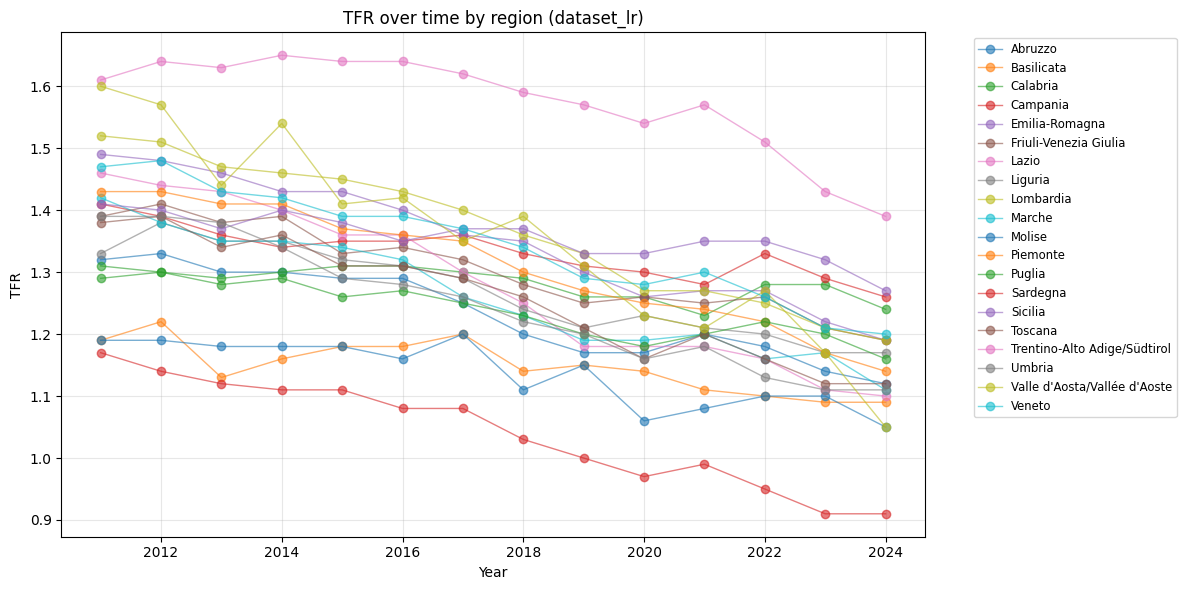

In [52]:
fig, ax = plt.subplots(figsize=(12, 6))
for region, grp in lt.sort_values(['region','year']).groupby('region'):
    ax.plot(grp['year'], grp['tfr'], marker='o', linewidth=1, alpha=0.6, label=region)
ax.set_title('TFR over time by region (dataset_lr)')
ax.set_xlabel('Year')
ax.set_ylabel('TFR')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
plt.tight_layout()
plt.show()


As you can see:
- TFR declines over time in almost all regions, indicating a strong common downward trend.
- Regions start from different fertility levels and largely retain their relative ranking, pointing to persistent regional heterogeneity.
- Despite this, there is substantial within-region variation over time, suggesting fertility responds to changing local conditions.
- The broadly synchronized movements across regions motivate the inclusion of year fixed effects, while stable level differences motivate region fixed effects.
- Together, these patterns support a two-way fixed-effects panel approach focused on within-region fertility dynamics.


## 3.2 Pairwise Correlations Among Predictors
Compute the correlation matrix across predictors (excluding `region` and `tfr`).


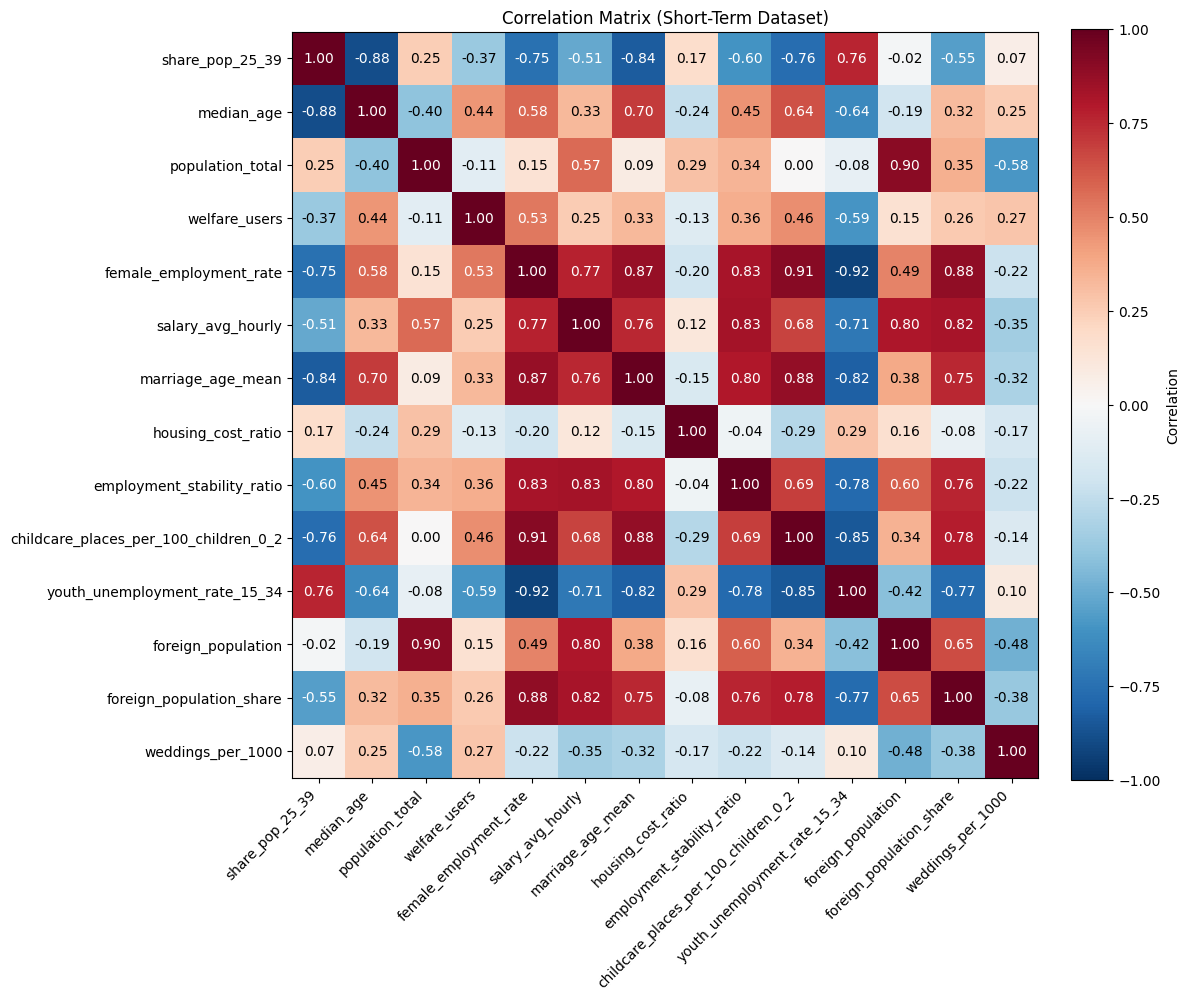

In [53]:
# Correlation matrix heatmap (short-term dataset)
corr_matrix = st.drop(columns=['year', 'tfr', 'region']).corr(numeric_only=True)

fig_w = max(12, 0.8 * len(corr_matrix.columns))
fig_h = max(10, 0.8 * len(corr_matrix.columns))
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)

# Annotate each cell with the correlation value
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')
ax.set_title('Correlation Matrix (Short-Term Dataset)')
plt.tight_layout()
plt.show()


In [54]:
predictors = [c for c in lt.columns if c not in ['region', 'tfr']]
corr_matrix = lt[predictors].corr(numeric_only=True)
corr_matrix


,year,share_pop_25_39,median_age,population_total,welfare_users,weddings_per_1000,marriage_age_mean,housing_cost_ratio
year,1.000000,-0.751716,0.679984,-0.034165,-0.058173,-0.035315,0.661335,-0.530046
share_pop_25_39,-0.751716,1.000000,-0.914885,0.160414,-0.196071,0.073343,-0.880457,0.320165
median_age,0.679984,-0.914885,1.000000,-0.295067,0.294192,0.121025,0.850500,-0.358226
population_total,-0.034165,0.160414,-0.295067,1.000000,-0.056572,-0.616961,0.043286,0.340632
welfare_users,-0.058173,-0.196071,0.294192,-0.056572,1.000000,0.137037,0.271121,-0.082291
weddings_per_1000,-0.035315,0.073343,0.121025,-0.616961,0.137037,1.000000,-0.248192,-0.229076
marriage_age_mean,0.661335,-0.880457,0.850500,0.043286,0.271121,-0.248192,1.000000,-0.280263
housing_cost_ratio,-0.530046,0.320165,-0.358226,0.340632,-0.082291,-0.229076,-0.280263,1.000000



## 3.3 Multicollinearity Check (VIF)
Variance Inflation Factors (VIF) for predictors to assess multicollinearity.


In [76]:
# VIF calculation on long-term dataset (lt)
vif_cols = [
    col for col in lt.columns
    if col not in {'region', 'year', 'tfr'}
    and pd.api.types.is_numeric_dtype(lt[col])
]

vif_ready = lt.dropna(subset=vif_cols)

if len(vif_cols) < 2 or len(vif_ready) <= len(vif_cols):
    print("Skipping VIF: insufficient rows or columns")
else:
    X = vif_ready[vif_cols].astype(float)

    # drop constant columns (prevents singularities)
    X = X.loc[:, X.std(numeric_only=True) > 0]

    X_np = X.to_numpy()
    vif = pd.DataFrame({
        "feature": X.columns,
        "vif": [variance_inflation_factor(X_np, i) for i in range(X_np.shape[1])],
    })

    display(vif.sort_values("vif", ascending=False))

,feature,vif
1,median_age,2424.279077
5,marriage_age_mean,2029.095580
6,housing_cost_ratio,114.490384
0,share_pop_25_39,96.625986
3,welfare_users,9.312719
2,population_total,6.370337
4,weddings_per_1000,3.814285


In [69]:
# VIF calculation on long-term dataset (lt)
vif_cols = [
    col for col in lt.columns
    if col not in {'population_total', 'share_pop_25_39', 'median_age', 'region', 'year', 'tfr'}
    and pd.api.types.is_numeric_dtype(lt[col])
]

vif_ready = lt.dropna(subset=vif_cols)

if len(vif_cols) < 2 or len(vif_ready) <= len(vif_cols):
    print("Skipping VIF: insufficient rows or columns")
else:
    X = vif_ready[vif_cols].astype(float)

    # drop constant columns (prevents singularities)
    X = X.loc[:, X.std(numeric_only=True) > 0]

    X_np = X.to_numpy()
    vif = pd.DataFrame({
        "feature": X.columns,
        "vif": [variance_inflation_factor(X_np, i) for i in range(X_np.shape[1])],
    })

    display(vif.sort_values("vif", ascending=False))

,feature,vif
2,marriage_age_mean,62.859722
3,housing_cost_ratio,51.970773
0,welfare_users,9.173563
1,weddings_per_1000,1.725895


In [59]:
vif_cols = [
    col for col in st.columns
    if col not in {'share_pop_25_39', 'median_age', 'region', 'year', 'tfr'}
    and pd.api.types.is_numeric_dtype(st[col])
]

vif_ready = st.dropna(subset=vif_cols)

# Need enough rows and at least 2 predictors for VIF to make sense
if len(vif_cols) < 2 or len(vif_ready) <= len(vif_cols):
    print("Skipping VIF: insufficient rows or columns")
else:
    X = vif_ready[vif_cols].astype(float).to_numpy()

    vif = pd.DataFrame({
        "feature": vif_cols,
        "vif": [variance_inflation_factor(X, i) for i in range(X.shape[1])],
    })

    display(vif.sort_values("vif", ascending=False))

,feature,vif
4,marriage_age_mean,3399.944529
6,employment_stability_ratio,2569.976243
3,salary_avg_hourly,1782.673137
2,female_employment_rate,652.912003
5,housing_cost_ratio,208.719091
7,childcare_places_per_100_children_0_2,108.999098
10,foreign_population_share,82.400585
0,population_total,73.074279
9,foreign_population,64.188596
8,youth_unemployment_rate_15_34,41.767109


In [75]:
vif_cols = [
    col for col in st.columns
    if col not in {'childcare_places_per_100_children_0_2', 'youth_unemployment_rate_15_34', 'foreign_population_share', 'employment_stability_ratio', 'salary_avg_hourly', 'population_total', 'foreign_population', 'share_pop_25_39', 'median_age', 'region', 'year', 'tfr'}
    and pd.api.types.is_numeric_dtype(st[col])
]

vif_ready = st.dropna(subset=vif_cols)

# Need enough rows and at least 2 predictors for VIF to make sense
if len(vif_cols) < 2 or len(vif_ready) <= len(vif_cols):
    print("Skipping VIF: insufficient rows or columns")
else:
    X = vif_ready[vif_cols].astype(float).to_numpy()

    vif = pd.DataFrame({
        "feature": vif_cols,
        "vif": [variance_inflation_factor(X, i) for i in range(X.shape[1])],
    })

    display(vif.sort_values("vif", ascending=False))

,feature,vif
2,marriage_age_mean,248.401477
3,housing_cost_ratio,107.759850
1,female_employment_rate,75.447541
0,welfare_users,12.987416
4,weddings_per_1000,2.215753
